### Handling Missing Values

In [10]:
import seaborn as sns

In [11]:
import pandas as pd
df = pd.read_csv("/Users/saicharan/Datascience/9 - FEATURE ENGINEERING WITH PYTHON/data/Instruments_Reviews.csv")

In [12]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [13]:
## Checking Missing Values
df.head().sum()

reviewerID        A2IBPI20UZIR0UA14VAT5EAX3D9SA195EZSQDW3E21A2C0...
asin              1384719342138471934213847193421384719342138471...
reviewerName      cassandra tu "Yeah, well, that's just like, u....
helpful                            [0, 0][13, 14][1, 1][0, 0][0, 0]
reviewText        Not much to write about here, but it does exac...
overall                                                        25.0
summary           goodJakeIt Does The Job WellGOOD WINDSCREEN FO...
unixReviewTime                                           6919862400
reviewTime        02 28, 201403 16, 201308 28, 201302 14, 201402...
dtype: object

In [14]:
df.shape

(10261, 9)

In [15]:
# handling missing values with column wise data
df.dropna().shape

(10227, 9)

In [16]:
# handling missing values with row wise data
df.dropna(axis=1).shape

(10261, 7)

### Imputation Missing Values Technique

**1 - Mean Value Imputation**
**Mean Imputation works well when we have normally distributed data**

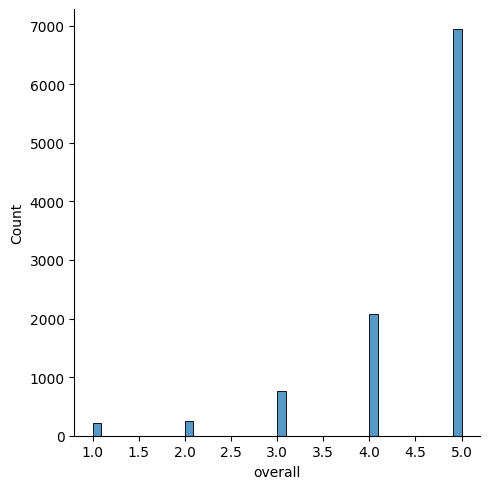

In [17]:
sns.displot(df['overall'])

### Imputation Mode Technique


In [24]:
# Getting null value which are in reviewerName column
df[df['reviewerName'].isnull()]

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,reviewerName_mode,unixReviewTime_median,overall_mean
41,AA5TINW2RJ195,B000068NW5,NaN,"[0, 0]",Good quality cable and sounds very good,5.0,Five Stars,1405382400,"07 15, 2014",Amazon Customer,1405382400,5.0
263,A14VAT5EAX3D9S,B0002CZSJO,NaN,"[0, 0]",It is exactly what you need in a capo! You can...,5.0,Great,1364860800,"04 2, 2013",Amazon Customer,1364860800,5.0
264,A2RVY2GDMZHH4,B0002CZSJO,NaN,"[0, 0]",Love these capos and nice that you can get the...,5.0,Always great Kyser,1356652800,"12 28, 2012",Amazon Customer,1356652800,5.0
432,A3BMYEA3J6RBVV,B0002CZVB4,NaN,"[0, 0]",Bought it as a gift. Friend loved it very much.,5.0,Friend loved it very much,1405209600,"07 13, 2014",Amazon Customer,1405209600,5.0
667,AA5TINW2RJ195,B0002D01K4,NaN,"[0, 0]",At first it look small for my guitar but it fi...,5.0,Love it!,1405382400,"07 15, 2014",Amazon Customer,1405382400,5.0
1001,A3NHUK1ISMZCFZ,B0002D0DWK,NaN,"[0, 0]",The best buy for your bass drum,5.0,Five Stars,1405814400,"07 20, 2014",Amazon Customer,1405814400,5.0
2197,A3NK6WKA7GKRZS,B0002FOBJY,NaN,"[0, 0]",Classic design. I remember these from 35 year...,5.0,Excellent music stand,1385510400,"11 27, 2013",Amazon Customer,1385510400,5.0
2233,A2T8JRVJRVNX8R,B0002GJ6FC,NaN,"[0, 0]",This headstand works like a charm. It's simple...,5.0,Best overall value,1405209600,"07 13, 2014",Amazon Customer,1405209600,5.0
2591,AA5TINW2RJ195,B0002GXV2Q,NaN,"[0, 0]","Good short cable, plugs easy",4.0,Four Stars,1405382400,"07 15, 2014",Amazon Customer,1405382400,4.0
3962,A3NHUK1ISMZCFZ,B0009EU01G,NaN,"[0, 0]",They say there the best there not wrong wool a...,5.0,Five Stars,1405814400,"07 20, 2014",Amazon Customer,1405814400,5.0


In [25]:
df['reviewerName'].unique()

array(['cassandra tu "Yeah, well, that\'s just like, u...', 'Jake',
       'Rick Bennette "Rick Bennette"', ...,
       'Amazon Customer "kateTaylor"', 'ManUPT', 'coffeebrain'],
      shape=(1398,), dtype=object)

In [26]:
# skipping Null Values

df[df['reviewerName'].notna()]['reviewerName'].mode()

0    Amazon Customer
Name: reviewerName, dtype: object

In [27]:
df['reviewerName_mode']=df[df['reviewerName'].notna()]['reviewerName'].mode()

In [18]:
# Replace missing values with the mode because here reviewer name is string 
df['reviewerName_mode'] = df['reviewerName'].fillna(df['reviewerName'].mode()[0])

In [19]:
df[['reviewerName_mode','reviewerName']]

,reviewerName_mode,reviewerName
0,"cassandra tu ""Yeah, well, that's just like, u...","cassandra tu ""Yeah, well, that's just like, u..."
1,Jake,Jake
2,"Rick Bennette ""Rick Bennette""","Rick Bennette ""Rick Bennette"""
3,"RustyBill ""Sunday Rocker""","RustyBill ""Sunday Rocker"""
4,SEAN MASLANKA,SEAN MASLANKA
...,...,...
10256,Lonnie M. Adams,Lonnie M. Adams
10257,Michael J. Edelman,Michael J. Edelman
10258,Michael L. Knapp,Michael L. Knapp
10259,"Rick Langdon ""Scriptor""","Rick Langdon ""Scriptor"""


### Median Value Imputation

**we use this if have outliers in the dataset**

In [20]:
df['unixReviewTime_median'] = df['unixReviewTime'].fillna(df['unixReviewTime'].median())

In [21]:
df[['unixReviewTime_median','unixReviewTime']]

,unixReviewTime_median,unixReviewTime
0,1393545600,1393545600
1,1363392000,1363392000
2,1377648000,1377648000
3,1392336000,1392336000
4,1392940800,1392940800
...,...,...
10256,1405814400,1405814400
10257,1404259200,1404259200
10258,1405987200,1405987200
10259,1404172800,1404172800


### Imputing Technique Mean

In [22]:
df['overall_mean']=df['overall'].fillna(df['overall'].mean())

In [23]:
df[['overall_mean','overall']]

,overall_mean,overall
0,5.0,5.0
1,5.0,5.0
2,5.0,5.0
3,5.0,5.0
4,5.0,5.0
...,...,...
10256,5.0,5.0
10257,5.0,5.0
10258,4.0,4.0
10259,4.0,4.0
